# BreaKHis Preprocessing and Dataloaders

## Objective
This notebook turns the corrected split into something I can actually train on. The main job here is to make the preprocessing choices visible, because things like normalisation and augmentation look small on paper but they change the character of histology images quite quickly.


In [1]:
from __future__ import annotations

import json
import random
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
plt.style.use('seaborn-v0_8-whitegrid')

CWD = Path.cwd().resolve()
if (CWD / 'src').exists() and (CWD / 'data').exists():
    PROJECT_ROOT = CWD
elif (CWD.parent / 'src').exists() and (CWD.parent / 'data').exists():
    PROJECT_ROOT = CWD.parent
elif (CWD.parent.parent / 'src').exists() and (CWD.parent.parent / 'data').exists():
    PROJECT_ROOT = CWD.parent.parent
else:
    raise RuntimeError(f'Could not resolve dissertation_project root from {CWD}')

REPO_ROOT = PROJECT_ROOT.parent
OUTPUTS = PROJECT_ROOT / 'outputs_v2'
FIGURES = OUTPUTS / 'figures'
METRICS = OUTPUTS / 'metrics'
REPORTS = OUTPUTS / 'reports'
MODELS = PROJECT_ROOT / 'models'
DATA_ROOT = PROJECT_ROOT / 'data' / 'dataset_cancer_v1' / 'dataset_cancer_v1'
WISCONSIN_ROOT = PROJECT_ROOT / 'notebook_Wisconsin'

for path in [FIGURES, METRICS, REPORTS]:
    path.mkdir(parents=True, exist_ok=True)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

print('Project root:', PROJECT_ROOT)
print('Outputs:', OUTPUTS)

from PIL import Image
import torch
from IPython.display import display

from src.breakhis import patient_level_split, build_binary_records, sample_per_patient
from src.image_pipeline import BREAKHIS_MEAN, BREAKHIS_STD, build_transforms, create_dataloaders, resolve_device

df = build_binary_records(DATA_ROOT)
split = patient_level_split(df, random_state=SEED)
train_dev = sample_per_patient(split.train, per_magnification=2, random_state=SEED)
val_dev = sample_per_patient(split.val, per_magnification=1, random_state=SEED)
test_dev = sample_per_patient(split.test, per_magnification=1, random_state=SEED)
train_dev.to_csv(REPORTS / 'breakhis_dev_train_sampled.csv', index=False)
val_dev.to_csv(REPORTS / 'breakhis_dev_val_sampled.csv', index=False)
test_dev.to_csv(REPORTS / 'breakhis_dev_test_sampled.csv', index=False)

print('Development train rows:', len(train_dev))
print('Development val rows:', len(val_dev))
print('Development test rows:', len(test_dev))
print('Chosen device:', resolve_device())


Project root: /Users/sergeysotskiy/Documents/UNI/year 3/Dissertation/dissertation_project
Outputs: /Users/sergeysotskiy/Documents/UNI/year 3/Dissertation/dissertation_project/outputs_v2


Development train rows: 455
Development val rows: 48
Development test rows: 52
Chosen device: mps


## Normalisation Choices

I started with ImageNet normalisation because that is the default transfer-learning recipe almost everywhere, then compared it against statistics estimated from BreaKHis itself. Once I looked at the colour distribution and sample tiles more carefully, dataset-specific normalisation felt like the safer default for this dataset, even though I still wanted the ImageNet version visible as a reference point.


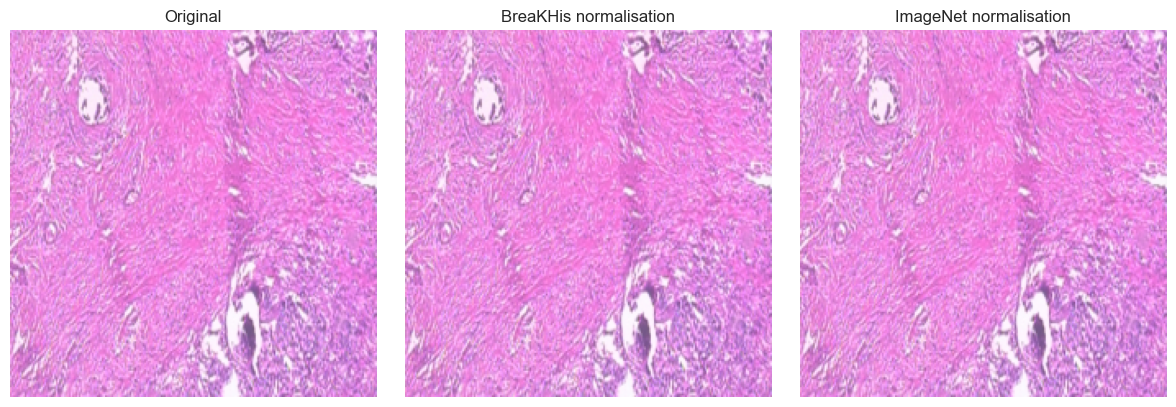

In [2]:
sample_row = train_dev.sample(1, random_state=SEED).iloc[0]
with Image.open(sample_row['filepath']) as image:
    image = image.convert('RGB')
    raw = np.asarray(image)

train_breakhis, eval_breakhis = build_transforms(normalization='breakhis', augment=False)
train_imagenet, eval_imagenet = build_transforms(normalization='imagenet', augment=False)

breakhis_tensor = eval_breakhis(image).permute(1, 2, 0).numpy()
imagenet_tensor = eval_imagenet(image).permute(1, 2, 0).numpy()

# inverse transforms for visual comparison
breakhis_vis = np.clip((breakhis_tensor * np.array(BREAKHIS_STD)) + np.array(BREAKHIS_MEAN), 0, 1)
imagenet_vis = np.clip((imagenet_tensor * np.array([0.229, 0.224, 0.225])) + np.array([0.485, 0.456, 0.406]), 0, 1)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(raw)
axes[0].set_title('Original')
axes[1].imshow(breakhis_vis)
axes[1].set_title('BreaKHis normalisation')
axes[2].imshow(imagenet_vis)
axes[2].set_title('ImageNet normalisation')
for ax in axes:
    ax.axis('off')
fig.tight_layout()
fig.savefig(FIGURES / 'breakhis_normalisation_comparison.png', dpi=300)
plt.show()


In [3]:
dataloaders = create_dataloaders(
    train_dev,
    val_dev,
    test_dev,
    batch_size=16,
    normalization='breakhis',
    augment=True,
)
images, labels = next(iter(dataloaders['train']))
print('Train batch shape:', tuple(images.shape))
print('Train labels shape:', tuple(labels.shape))
print('Label counts in first batch:', pd.Series(labels.numpy()).value_counts().to_dict())


Train batch shape: (16, 3, 224, 224)
Train labels shape: (16,)
Label counts in first batch: {1: 9, 0: 7}


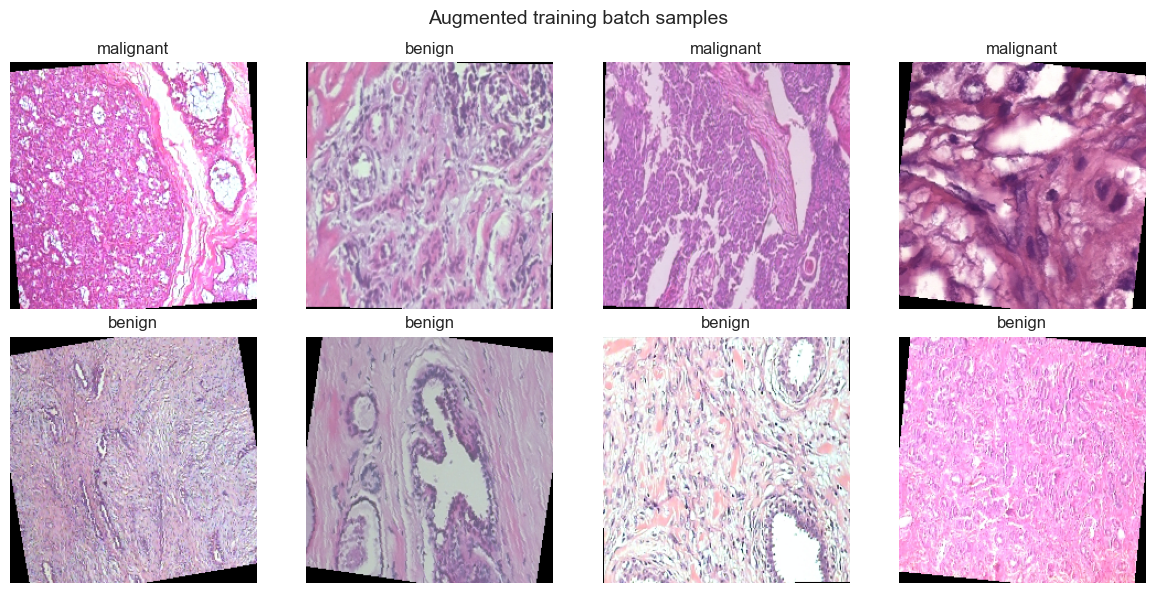

In [4]:
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for ax, idx in zip(axes.ravel(), range(8)):
    img = images[idx].permute(1, 2, 0).numpy()
    img = np.clip((img * np.array(BREAKHIS_STD)) + np.array(BREAKHIS_MEAN), 0, 1)
    ax.imshow(img)
    ax.set_title('malignant' if int(labels[idx]) == 1 else 'benign')
    ax.axis('off')
fig.suptitle('Augmented training batch samples', fontsize=14)
fig.tight_layout()
fig.savefig(FIGURES / 'breakhis_augmented_batch_examples.png', dpi=300)
plt.show()


## Interpretation

I kept dataset-specific normalisation with mild augmentation as the main setup. That choice is less flashy, but it matched what I was seeing in the tiles. When the augmentations became too aggressive, especially on colour, the tissue started to look less like histology and more like a synthetic image transformation. I would rather keep the pipeline conservative than claim robustness from distortions that do not look biologically plausible.
